# **IndoBERT finetuning**

Import Library

In [ ]:
# Untuk mempercepat training
%pip install accelerate -U

In [ ]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

In [ ]:
import random
import time
import datetime

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import softmax
from torch.nn import CrossEntropyLoss
from datasets import Dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          TrainingArguments,Trainer,
                           EarlyStoppingCallback,
                          DataCollatorWithPadding)
from sklearn.metrics import (classification_report,
                             confusion_matrix, accuracy_score,
                             precision_score,recall_score,
                             f1_score)
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Load data yang telah diproses
train_df = pd.read_csv('train_dataset.csv')
val_df = pd.read_csv('val_dataset.csv')
test_df = pd.read_csv('test_dataset.csv')

# Menampilkan jumlah data masing-masing
print(f"Jumlah data latih: {len(train_df)}")
print(f"Jumlah data validasi: {len(val_df)}")
print(f"Jumlah data uji: {len(test_df)}")

Jumlah data latih: 3094
Jumlah data validasi: 442
Jumlah data uji: 884


In [ ]:
print("Distribusi label data latih:")
print(train_df["label_num"].value_counts().sort_index())

print("Distribusi label data validasi:")
print(val_df["label_num"].value_counts().sort_index())

print("Distribusi label data uji:")
print(test_df["label_num"].value_counts().sort_index())

Distribusi label data latih:
label_num
0     464
1    1070
2    1560
Name: count, dtype: int64
Distribusi label data validasi:
label_num
0     65
1    153
2    224
Name: count, dtype: int64
Distribusi label data uji:
label_num
0    147
1    309
2    428
Name: count, dtype: int64



Tokenizer dan Dataset Format

In [ ]:
# Load Model dan Tokenizer
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# konversi ke hugging face dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Fungsi tokenisasi
# Padding dilakukan secara dinamis melalui DataCollatorWithPadding
def tokenize_function(examples):
    return tokenizer(examples['normalized'], truncation=True, max_length=64)

# Tokenisasi dataset
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/3094 [00:00<?, ? examples/s]

Map:   0%|          | 0/442 [00:00<?, ? examples/s]

Map:   0%|          | 0/884 [00:00<?, ? examples/s]


Set format dataset ke format PyTorch

In [ ]:
train_dataset = train_dataset.rename_column("label_num", "labels")
val_dataset = val_dataset.rename_column("label_num", "labels")
test_dataset = test_dataset.rename_column("label_num", "labels")

# hanya ambil kolom input_ids, attention_mask, dan labels
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Model Setup

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

training_args = TrainingArguments(
    output_dir="../training_args_final",
    eval_strategy="epoch",  # Evaluasi dilakukan di akhir setiap epoch
    save_strategy="epoch",  # Simpan model di akhir setiap epoch
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.05,
    optim="adamw_torch",
    logging_dir='./logs_final',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='weighted_f1',
    greater_is_better=True,
    save_total_limit=3,  # Simpan hanya 3 model terbaik
    seed=42,
    data_seed=42
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Define metric evaluasi

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, average="weighted", zero_division=0),
        "recall": recall_score(labels, predictions, average="weighted", zero_division=0),
        "f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0)
    }

Trainer Setup

In [ ]:
# Hitung class weights dari data train
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label_num'].values)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class weights:", class_weights)

# Custom Trainer dengan weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

Class weights: tensor([2.2227, 0.9639, 0.6611])


## **Fine-tuning IndoBERT**

In [ ]:
# Mulai mencatat waktu
start_time = time.time()

# Melatih model
trainer.train()

# Selesai mencatat waktu
end_time = time.time()

# Menghitung durasi
training_duration = end_time - start_time

# Tampilkan durasi dalam format jam:menit:detik
import datetime
formatted_duration = str(datetime.timedelta(seconds=int(training_duration)))
print(f"Durasi pelatihan: {formatted_duration}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Weighted F1
1,0.346787,0.376745,0.848416,0.868570,0.848416,0.828176,0.852272
2,0.282170,0.425926,0.884615,0.884879,0.884615,0.871604,0.884472
3,0.106591,0.577480,0.884615,0.884639,0.884615,0.875476,0.884577
4,0.013568,0.576969,0.880090,0.880734,0.880090,0.865791,0.880162


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Durasi pelatihan: 0:03:20



# **Evaluasi model**

In [ ]:
results = trainer.evaluate(test_dataset)
print(results)

{'eval_loss': 0.46343645453453064, 'eval_accuracy': 0.9083710407239819, 'eval_precision': 0.9096125969478084, 'eval_recall': 0.9083710407239819, 'eval_f1': 0.9057073676928399, 'eval_weighted_f1': 0.9077022725648278, 'eval_runtime': 2.8785, 'eval_samples_per_second': 307.099, 'eval_steps_per_second': 19.454, 'epoch': 4.0}


In [ ]:
# Simpan model
trainer.save_model("indoBERT_finetuning")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(-1)

In [ ]:
target_names = ['positif', 'netral', 'negatif']
print(classification_report(test_dataset["labels"],
                            pred_labels,
                            target_names=target_names,
                            zero_division=0))

              precision    recall  f1-score   support

     positif       0.91      0.91      0.91       147
      netral       0.93      0.84      0.88       309
     negatif       0.89      0.96      0.92       428

    accuracy                           0.91       884
   macro avg       0.91      0.90      0.91       884
weighted avg       0.91      0.91      0.91       884



In [ ]:
y_true = test_dataset["labels"]
y_pred = pred_labels

accuracy_value = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy_value)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1-score:", macro_f1)
print("Weighted Precision:", weighted_precision)
print("Weighted Recall:", weighted_recall)
print("Weighted F1-score:", weighted_f1)

Accuracy: 0.9083710407239819
Macro Precision: 0.9107574080751183
Macro Recall: 0.9028653502353062
Macro F1-score: 0.9057073676928399
Weighted Precision: 0.9096125969478084
Weighted Recall: 0.9083710407239819
Weighted F1-score: 0.9077022725648278


## **Visualisasi model**

In [ ]:
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
true_labels = pred_output.label_ids
pred_labels = np.argmax(logits, axis=1)

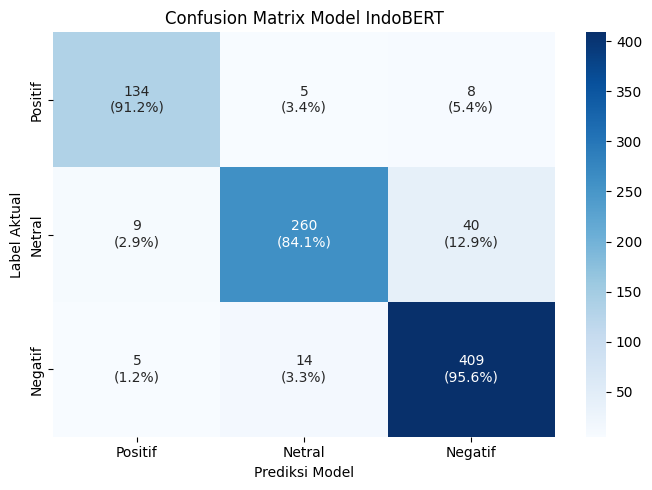

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

target_names = ["Positif", "Netral", "Negatif"]

# Confusion matrix angka absolut
cm = confusion_matrix(true_labels, pred_labels)

# Persentase per baris berdasarkan label aktual
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Gabungkan angka absolut dan persentase dalam satu label
annot_labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_labels[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True
)

plt.xlabel("Prediksi Model")
plt.ylabel("Label Aktual")
plt.title("Confusion Matrix Model IndoBERT")
plt.tight_layout()

plt.savefig("confusion_matrix_persen_indobert.png", dpi=300)
plt.show()

## **Test model**

In [ ]:
def predict_sentiment_debug(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if CUDA is available
    model.to(device)  # Move model to the appropriate device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64).to(device)  # Move inputs to the same device
    outputs = model(**inputs)
    probs = softmax(outputs.logits, dim=-1)  # Hitung probabilitas
    label_map = {0: "positif", 1: "netral", 2: "negatif"}  # Mapping label
    for i, prob in enumerate(probs[0]):
        print(f"{label_map[i]}: {prob.item() * 100:.3f}%")
    predicted_class = torch.argmax(probs, dim=-1).item()  # Ambil label prediksi
    confidence = probs[0][predicted_class].item() * 100  # Ambil probabilitas prediksi
    return label_map[predicted_class], confidence


In [ ]:
# Contoh teks untuk prediksi
text = "males banget banyak yang curang ngerjain tka"
label, confidence = predict_sentiment_debug(text)

# Output hasil prediksi
print(f"Text: {text} | Label: {label} ({confidence:.3f}%)")

positif: 0.044%
netral: 0.039%
negatif: 99.917%
Text: males banget banyak yang curang ngerjain tka | Label: negatif (99.917%)


In [ ]:
text = "alhamdulillah kelar ngerjain tka, semoga hasilnya bagus"
label, confidence = predict_sentiment_debug(text)

# Output hasil prediksi
print(f"Text: {text} | Label: {label} ({confidence:.3f}%)")

positif: 99.923%
netral: 0.053%
negatif: 0.024%
Text: alhamdulillah kelar ngerjain tka, semoga hasilnya bagus | Label: positif (99.923%)


In [ ]:
# Contoh teks untuk prediksi
text = "pengumuman sosialisasi tka udah muncul guys"
label, confidence = predict_sentiment_debug(text)

# Output hasil prediksi
print(f"Text: {text} | Label: {label} ({confidence:.3f}%)")

positif: 0.049%
netral: 99.910%
negatif: 0.041%
Text: pengumuman sosialisasi tka udah muncul guys | Label: netral (99.910%)


# Analisis

In [ ]:
hasil_prediksi = test_df.copy()
hasil_prediksi["prediksi_model"] = pred_labels

label_map = {0: "positif", 1: "netral", 2: "negatif"}
hasil_prediksi["label_aktual"] = hasil_prediksi["label_num"].map(label_map)
hasil_prediksi["prediksi_label"] = hasil_prediksi["prediksi_model"].map(label_map)
hasil_prediksi.to_csv("hasil_prediksi_indobert.csv", index=False)

In [ ]:
hasil_prediksi["status_prediksi"] = hasil_prediksi.apply(
    lambda row: "Benar" if row["label_aktual"] == row["prediksi_label"] else "Salah",
    axis=1
)
print(hasil_prediksi["status_prediksi"].value_counts())
hasil_prediksi["status_prediksi"].value_counts(normalize=True) * 100

status_prediksi
Benar    803
Salah     81
Name: count, dtype: int64


,proportion
status_prediksi,
Benar,90.837104
Salah,9.162896


In [ ]:
distribusi_perbandingan = pd.DataFrame({
    "Label Aktual": hasil_prediksi["label_aktual"].value_counts(),
    "Prediksi Model": hasil_prediksi["prediksi_label"].value_counts()
})

distribusi_perbandingan

,Label Aktual,Prediksi Model
negatif,428,457
netral,309,279
positif,147,148


In [ ]:
logits = preds.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()

hasil_prediksi["prob_positif"] = probs[:, 0]
hasil_prediksi["prob_netral"] = probs[:, 1]
hasil_prediksi["prob_negatif"] = probs[:, 2]
hasil_prediksi["confidence_model"] = probs.max(axis=1)

In [ ]:
hasil_prediksi.groupby("status_prediksi")["confidence_model"].describe()

,count,mean,std,min,25%,50%,75%,max
status_prediksi,,,,,,,,
Benar,803.0,0.986418,0.053675,0.338440,0.998096,0.998987,0.999158,0.999322
Salah,81.0,0.916330,0.138512,0.483547,0.904873,0.984259,0.998523,0.999170


In [ ]:
salah_conf_tinggi = hasil_prediksi[
    (hasil_prediksi["status_prediksi"] == "Salah") &
    (hasil_prediksi["confidence_model"] >= 0.8)
]

salah_conf_tinggi[[
    "normalized",
    "label_aktual",
    "prediksi_label",
    "confidence_model"
]].head(50)

,normalized,label_aktual,prediksi_label,confidence_model
7,banyak mendapat kabar kelas diwajibkan ikut tk...,netral,positif,0.938088
20,tolong tka di mundurin saja aku ikhlas kok,negatif,positif,0.961927
50,aku rencana tka mata pelajaran dua pilihan nya...,netral,negatif,0.996448
61,tka day bahasa indonesia masih lumayan gampang...,netral,negatif,0.998822
62,eh informasi tka udah muncul guys mixed feelin...,netral,positif,0.992090
85,last ya last benaran last gasi masih ada rise ...,netral,negatif,0.870705
91,ayo angkatan kita temenan untuk membantai tka ...,positif,negatif,0.990209
94,kalian belajar tka tuh nyatet materi dulu atau...,netral,negatif,0.861834
103,kalau dibandingkan nilai tka mana yang lebih g...,netral,positif,0.958975
114,awal november banget tka,netral,positif,0.919527
